In [58]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt


In [59]:
df=pd.read_csv('placement-dataset.csv')

In [60]:
df

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
2,Chicago,NaN,121.0,0
3,New York,7.4,132.0,1
4,Los Angeles,5.8,142.0,0
...,...,...,...,...
95,Chicago,4.3,200.0,0
96,New York,4.4,42.0,0
97,Los Angeles,6.7,182.0,1
98,Chicago,6.3,103.0,1


In [61]:
df.head()

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
2,Chicago,NaN,121.0,0
3,New York,7.4,132.0,1
4,Los Angeles,5.8,142.0,0


In [62]:
sns.scatterplot(df['Hours'],hue=df['Scores'])

KeyError: 'Hours'

In [63]:
sns.scatterplot(df['cgpa'],df['iq'],df['city'],hue=df['placement'])

TypeError: scatterplot() takes from 0 to 1 positional arguments but 3 positional arguments (and 1 keyword-only argument) were given

<Axes: xlabel='cgpa', ylabel='iq'>

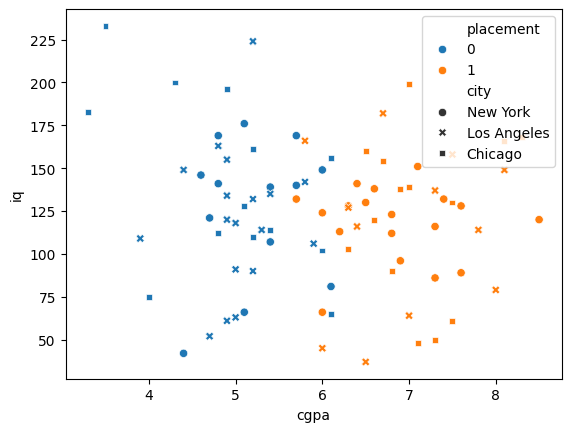

In [64]:
sns.scatterplot(
    data=df,
    x='cgpa',
    y='iq',
    style='city',
    hue='placement'
)

In [81]:
# from sklearn.impute import SimpleImputer
# from sklearn.linear_model import Perceptron
# from sklearn.linear_model import Perceptron
# from sklearn.preprocessing import LabelEncoder  

# X = df[['cgpa', 'iq']]
# y = df['placement']

X = df[['cgpa', 'iq']].values
y = df['placement'].values
print(df[['cgpa', 'iq']].isnull().sum())

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
# encoder = LabelEncoder()
# X['city'] = encoder.fit_transform(X['city'])

# df.dropna()
# df

cgpa    8
iq      4
dtype: int64


In [82]:
from sklearn.linear_model import Perceptron
p=Perceptron()

In [83]:
p.fit(X,y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [84]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Perceptron


imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)


p = Perceptron()
p.fit(X, y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [85]:
p.coef_

array([[404.75217391,  44.58333333]])

In [86]:
print(p.coef_)
print(p.intercept_)

[[404.75217391  44.58333333]]
[-49.]


In [87]:

!pip install mlxtend
import sys
!{sys.executable} -m pip install mlxtend

In [88]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

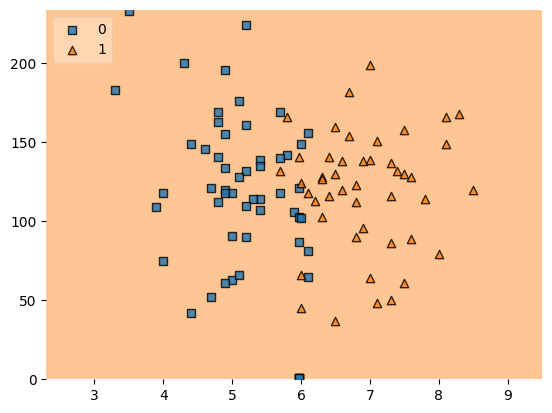

In [89]:
plot_decision_regions(X,y,clf=p,legend=2)

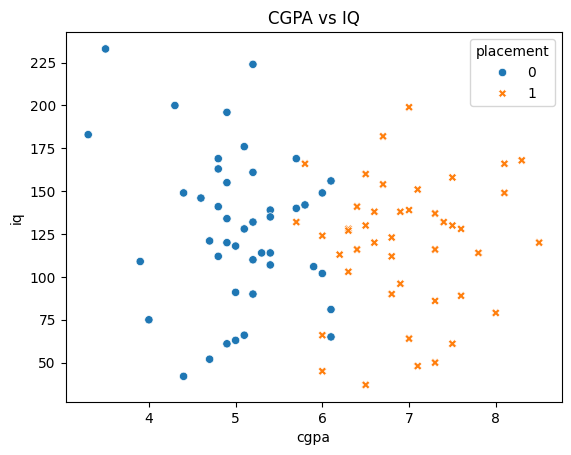

In [94]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_decision_regions



sns.scatterplot(
    data=df,
    x='cgpa',
    y='iq',
    hue='placement',
    style='placement'
)

plt.title('CGPA vs IQ')
plt.show()

In [95]:
# Input Features
X = df[['cgpa', 'iq']].values

# Output Feature
y = df['placement'].values

In [96]:
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

In [97]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
p = Perceptron(max_iter=1000)
p.fit(X, y)
print('Weights:', p.coef_)
print('Intercept:', p.intercept_)

Weights: [[ 6.85085394 -0.72898575]]
Intercept: [-1.]


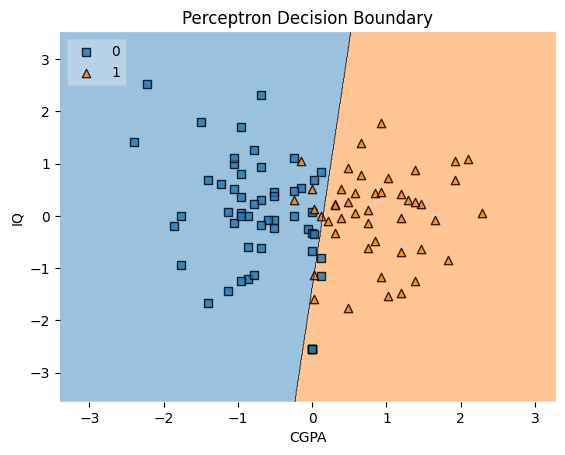

In [98]:
plot_decision_regions(
    X,
    y.astype(np.int_),
    clf=p,
    legend=2
)

plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Perceptron Decision Boundary')

plt.show()